In [18]:
import pandas as pd
import matplotlib.pyplot as plt

In [19]:
# Final test metrics for session_count forecasting
session_results = pd.DataFrame([
    {"Model": "Linear Regression", "Target": "session_count", "Test_MAE": 0.7168, "Test_RMSE": 1.0944, "Test_R2": 0.3039},
    {"Model": "Ridge",             "Target": "session_count", "Test_MAE": 0.7168, "Test_RMSE": 1.0944, "Test_R2": 0.3039},
    {"Model": "Lasso",             "Target": "session_count", "Test_MAE": 0.7164, "Test_RMSE": 1.0945, "Test_R2": 0.3039},
    {"Model": "Random Forest",     "Target": "session_count", "Test_MAE": 0.6909, "Test_RMSE": 1.1548, "Test_R2": 0.2249},
    {"Model": "Gradient Boosting", "Target": "session_count", "Test_MAE": 0.6666, "Test_RMSE": 1.0381, "Test_R2": 0.3737},
    {"Model": "LSTM",              "Target": "session_count", "Test_MAE": 0.7764, "Test_RMSE": 1.1440, "Test_R2": 0.2029},
])

# Final test metrics for total_kwh forecasting
kwh_results = pd.DataFrame([
    {"Model": "Linear Regression", "Target": "total_kwh", "Test_MAE": 10.5842, "Test_RMSE": 17.7100, "Test_R2": 0.1234},
    {"Model": "Random Forest",     "Target": "total_kwh", "Test_MAE": 10.4846, "Test_RMSE": 18.0751, "Test_R2": 0.0869},
    {"Model": "Gradient Boosting", "Target": "total_kwh", "Test_MAE": 10.0888, "Test_RMSE": 17.4482, "Test_R2": 0.1491},
    {"Model": "LSTM",              "Target": "total_kwh", "Test_MAE": 11.2504, "Test_RMSE": 18.5922, "Test_R2": 0.0320},
])

In [20]:
# Rounded tables for clean notebook display
session_table = session_results.copy()
kwh_table = kwh_results.copy()

for col in ["Test_MAE", "Test_RMSE", "Test_R2"]:
    session_table[col] = session_table[col].round(4)
    kwh_table[col] = kwh_table[col].round(4)

print("Session forecasting results")
display(session_table)

print("kWh forecasting results")
display(kwh_table)

Session forecasting results


,Model,Target,Test_MAE,Test_RMSE,Test_R2
0,Linear Regression,session_count,0.7168,1.0944,0.3039
1,Ridge,session_count,0.7168,1.0944,0.3039
2,Lasso,session_count,0.7164,1.0945,0.3039
3,Random Forest,session_count,0.6909,1.1548,0.2249
4,Gradient Boosting,session_count,0.6666,1.0381,0.3737
5,LSTM,session_count,0.7764,1.1440,0.2029


kWh forecasting results


,Model,Target,Test_MAE,Test_RMSE,Test_R2
0,Linear Regression,total_kwh,10.5842,17.7100,0.1234
1,Random Forest,total_kwh,10.4846,18.0751,0.0869
2,Gradient Boosting,total_kwh,10.0888,17.4482,0.1491
3,LSTM,total_kwh,11.2504,18.5922,0.0320


In [21]:
# Combine both targets into one table for quick comparison
all_results = pd.concat([session_results, kwh_results], ignore_index=True)
all_results = all_results.sort_values(["Target", "Test_RMSE"]).reset_index(drop=True)

display(all_results.round(4))

,Model,Target,Test_MAE,Test_RMSE,Test_R2
0,Gradient Boosting,session_count,0.6666,1.0381,0.3737
1,Linear Regression,session_count,0.7168,1.0944,0.3039
2,Ridge,session_count,0.7168,1.0944,0.3039
3,Lasso,session_count,0.7164,1.0945,0.3039
4,LSTM,session_count,0.7764,1.1440,0.2029
5,Random Forest,session_count,0.6909,1.1548,0.2249
6,Gradient Boosting,total_kwh,10.0888,17.4482,0.1491
7,Linear Regression,total_kwh,10.5842,17.7100,0.1234
8,Random Forest,total_kwh,10.4846,18.0751,0.0869
9,LSTM,total_kwh,11.2504,18.5922,0.0320


In [22]:
# Best model for each target based on lowest test RMSE
best_session = session_results.sort_values("Test_RMSE").iloc[0]
best_kwh = kwh_results.sort_values("Test_RMSE").iloc[0]

best_summary = pd.DataFrame([
    {
        "Target": "session_count",
        "Best Model": best_session["Model"],
        "Test MAE": round(best_session["Test_MAE"], 4),
        "Test RMSE": round(best_session["Test_RMSE"], 4),
        "Test R²": round(best_session["Test_R2"], 4),
    },
    {
        "Target": "total_kwh",
        "Best Model": best_kwh["Model"],
        "Test MAE": round(best_kwh["Test_MAE"], 4),
        "Test RMSE": round(best_kwh["Test_RMSE"], 4),
        "Test R²": round(best_kwh["Test_R2"], 4),
    },
])

print("Best model summary")
display(best_summary)

Best model summary


,Target,Best Model,Test MAE,Test RMSE,Test R²
0,session_count,Gradient Boosting,0.6666,1.0381,0.3737
1,total_kwh,Gradient Boosting,10.0888,17.4482,0.1491


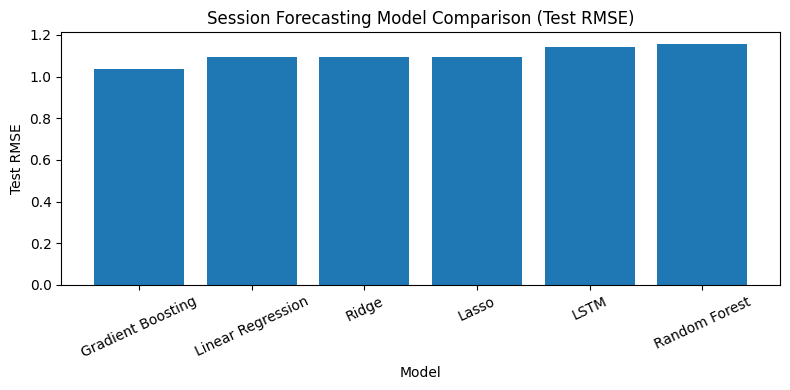

In [23]:
# Sort by lowest RMSE for session_count
session_rmse_df = session_results.sort_values("Test_RMSE")

plt.figure(figsize=(8, 4))
plt.bar(session_rmse_df["Model"], session_rmse_df["Test_RMSE"])
plt.title("Session Forecasting Model Comparison (Test RMSE)")
plt.xlabel("Model")
plt.ylabel("Test RMSE")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

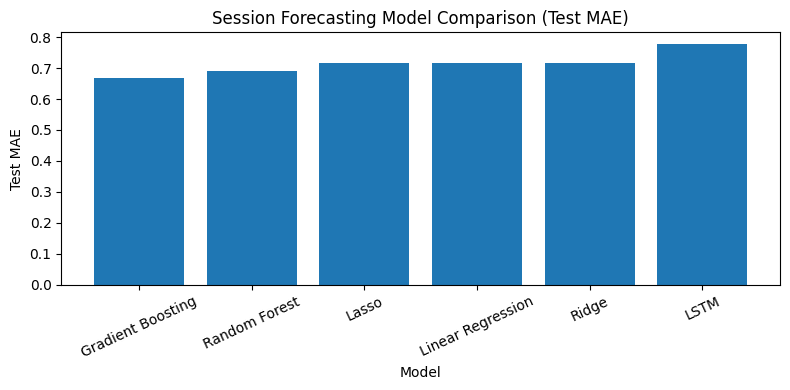

In [24]:
# Sort by lowest MAE for session_count
session_mae_df = session_results.sort_values("Test_MAE")

plt.figure(figsize=(8, 4))
plt.bar(session_mae_df["Model"], session_mae_df["Test_MAE"])
plt.title("Session Forecasting Model Comparison (Test MAE)")
plt.xlabel("Model")
plt.ylabel("Test MAE")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

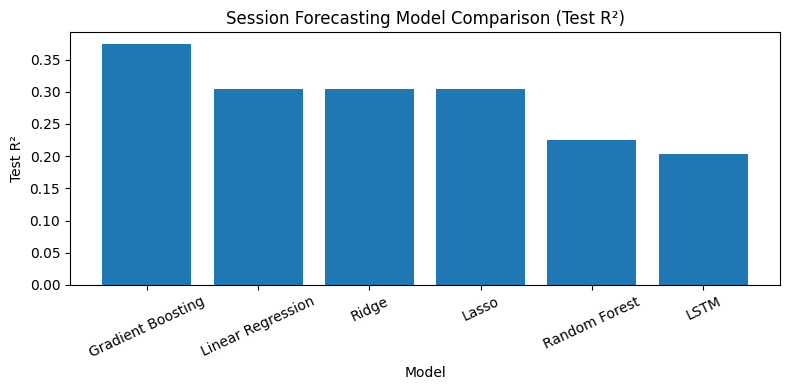

In [25]:
# Sort by highest R² for session_count
session_r2_df = session_results.sort_values("Test_R2", ascending=False)

plt.figure(figsize=(8, 4))
plt.bar(session_r2_df["Model"], session_r2_df["Test_R2"])
plt.title("Session Forecasting Model Comparison (Test R²)")
plt.xlabel("Model")
plt.ylabel("Test R²")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

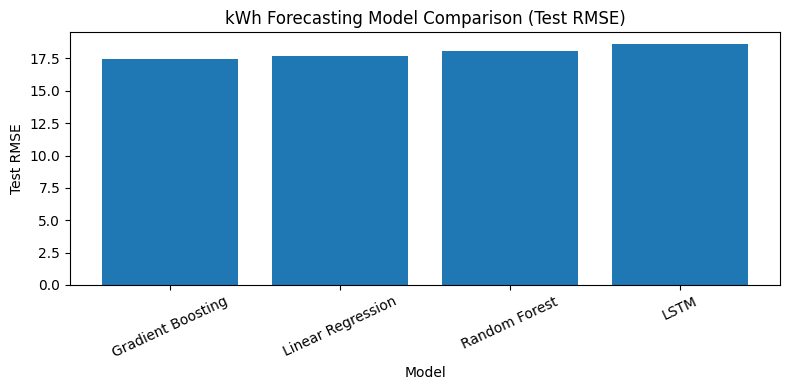

In [26]:
# Sort by lowest RMSE for total_kwh
kwh_rmse_df = kwh_results.sort_values("Test_RMSE")

plt.figure(figsize=(8, 4))
plt.bar(kwh_rmse_df["Model"], kwh_rmse_df["Test_RMSE"])
plt.title("kWh Forecasting Model Comparison (Test RMSE)")
plt.xlabel("Model")
plt.ylabel("Test RMSE")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

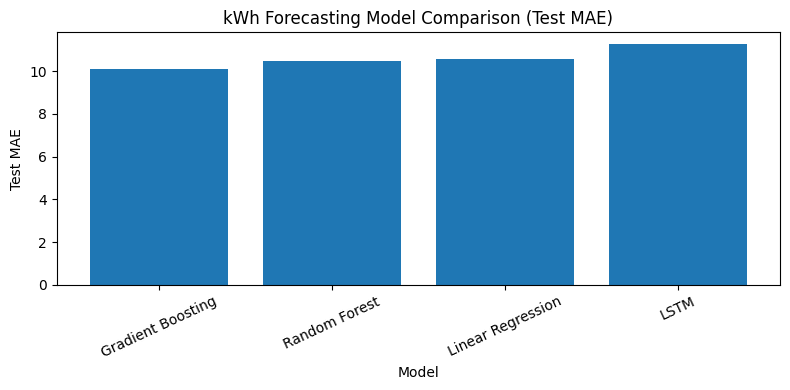

In [27]:
# Sort by lowest MAE for total_kwh
kwh_mae_df = kwh_results.sort_values("Test_MAE")

plt.figure(figsize=(8, 4))
plt.bar(kwh_mae_df["Model"], kwh_mae_df["Test_MAE"])
plt.title("kWh Forecasting Model Comparison (Test MAE)")
plt.xlabel("Model")
plt.ylabel("Test MAE")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

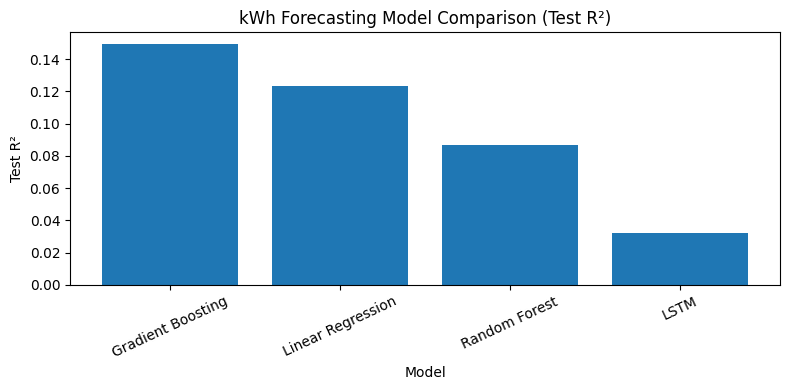

In [28]:
# Sort by highest R² for total_kwh
kwh_r2_df = kwh_results.sort_values("Test_R2", ascending=False)

plt.figure(figsize=(8, 4))
plt.bar(kwh_r2_df["Model"], kwh_r2_df["Test_R2"])
plt.title("kWh Forecasting Model Comparison (Test R²)")
plt.xlabel("Model")
plt.ylabel("Test R²")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

In [29]:
# Pivot-style tables for cleaner side-by-side metric reading
session_pivot = session_results.set_index("Model")[["Test_MAE", "Test_RMSE", "Test_R2"]].round(4)
kwh_pivot = kwh_results.set_index("Model")[["Test_MAE", "Test_RMSE", "Test_R2"]].round(4)

print("Session_count model comparison")
display(session_pivot)

print("Total_kwh model comparison")
display(kwh_pivot)

Session_count model comparison


,Test_MAE,Test_RMSE,Test_R2
Model,,,
Linear Regression,0.7168,1.0944,0.3039
Ridge,0.7168,1.0944,0.3039
Lasso,0.7164,1.0945,0.3039
Random Forest,0.6909,1.1548,0.2249
Gradient Boosting,0.6666,1.0381,0.3737
LSTM,0.7764,1.1440,0.2029


Total_kwh model comparison


,Test_MAE,Test_RMSE,Test_R2
Model,,,
Linear Regression,10.5842,17.7100,0.1234
Random Forest,10.4846,18.0751,0.0869
Gradient Boosting,10.0888,17.4482,0.1491
LSTM,11.2504,18.5922,0.0320


In [30]:
# Rank models for session_count
session_ranked = session_results.copy()
session_ranked["RMSE_Rank"] = session_ranked["Test_RMSE"].rank(method="min")
session_ranked["MAE_Rank"] = session_ranked["Test_MAE"].rank(method="min")
session_ranked["R2_Rank"] = session_ranked["Test_R2"].rank(method="min", ascending=False)
session_ranked = session_ranked.sort_values("RMSE_Rank")

# Rank models for total_kwh
kwh_ranked = kwh_results.copy()
kwh_ranked["RMSE_Rank"] = kwh_ranked["Test_RMSE"].rank(method="min")
kwh_ranked["MAE_Rank"] = kwh_ranked["Test_MAE"].rank(method="min")
kwh_ranked["R2_Rank"] = kwh_ranked["Test_R2"].rank(method="min", ascending=False)
kwh_ranked = kwh_ranked.sort_values("RMSE_Rank")

print("Session_count ranked models")
display(session_ranked.round(4))

print("Total_kwh ranked models")
display(kwh_ranked.round(4))

Session_count ranked models


,Model,Target,Test_MAE,Test_RMSE,Test_R2,RMSE_Rank,MAE_Rank,R2_Rank
4,Gradient Boosting,session_count,0.6666,1.0381,0.3737,1.0,1.0,1.0
0,Linear Regression,session_count,0.7168,1.0944,0.3039,2.0,4.0,2.0
1,Ridge,session_count,0.7168,1.0944,0.3039,2.0,4.0,2.0
2,Lasso,session_count,0.7164,1.0945,0.3039,4.0,3.0,2.0
5,LSTM,session_count,0.7764,1.1440,0.2029,5.0,6.0,6.0
3,Random Forest,session_count,0.6909,1.1548,0.2249,6.0,2.0,5.0


Total_kwh ranked models


,Model,Target,Test_MAE,Test_RMSE,Test_R2,RMSE_Rank,MAE_Rank,R2_Rank
2,Gradient Boosting,total_kwh,10.0888,17.4482,0.1491,1.0,1.0,1.0
0,Linear Regression,total_kwh,10.5842,17.7100,0.1234,2.0,3.0,2.0
1,Random Forest,total_kwh,10.4846,18.0751,0.0869,3.0,2.0,3.0
3,LSTM,total_kwh,11.2504,18.5922,0.0320,4.0,4.0,4.0
